# Stage 12 — Results Reporting and Delivery Design

## 1. Audience and format

The audience is an investment committee. A short Markdown report fits a decision meeting and keeps assumptions beside the charts.

In [1]:
from pathlib import Path
import os

import ipynbname

try:
    HOMEWORK_DIR = Path(ipynbname.path()).resolve().parent
except (FileNotFoundError, IndexError):
    HOMEWORK_DIR = Path.cwd().resolve()
    candidate = HOMEWORK_DIR / "homework" / "homework12"
    if candidate.is_dir():
        HOMEWORK_DIR = candidate
os.chdir(HOMEWORK_DIR)
print("Working from:", HOMEWORK_DIR.name)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROCESSED_DIR = HOMEWORK_DIR / "data" / "processed"
REPORTS_DIR = HOMEWORK_DIR / "reports"
IMAGES_DIR = REPORTS_DIR / "images"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

Working from: homework12


## 2. Self-contained scenario data

In [2]:
dates = pd.date_range("2023-01-31", periods=36, freq="ME")
returns = pd.DataFrame({
    "Momentum": rng.normal(0.008, 0.045, len(dates)),
    "Balanced": rng.normal(0.006, 0.028, len(dates)),
    "Defensive": rng.normal(0.004, 0.018, len(dates)),
}, index=dates)

summary = pd.DataFrame({
    "annual_return": (1 + returns).prod() ** (12 / len(returns)) - 1,
    "annual_volatility": returns.std() * np.sqrt(12),
})
summary["sharpe_zero_rf"] = summary["annual_return"] / summary["annual_volatility"]

cost_levels = pd.Series({"0 bps": 0.0, "10 bps": 0.001, "25 bps": 0.0025})
annual_turnover = 6.0
sensitivity = pd.DataFrame({
    "annual_return": summary.loc["Momentum", "annual_return"] - annual_turnover * cost_levels,
})
sensitivity["change_from_baseline"] = sensitivity["annual_return"] - sensitivity.iloc[0, 0]
returns.rename_axis("date").reset_index().to_csv(PROCESSED_DIR / "portfolio_returns.csv", index=False)
summary.to_csv(PROCESSED_DIR / "portfolio_summary.csv")
sensitivity.to_csv(PROCESSED_DIR / "cost_sensitivity.csv")
summary.round(4), sensitivity.round(4)

(           annual_return  annual_volatility  sharpe_zero_rf
 Momentum          0.1354             0.1308          1.0350
 Balanced          0.0611             0.0738          0.8279
 Defensive         0.0005             0.0442          0.0121,
         annual_return  change_from_baseline
 0 bps          0.1354                 0.000
 10 bps         0.1294                -0.006
 25 bps         0.1204                -0.015)

## 3. Decision-ready charts

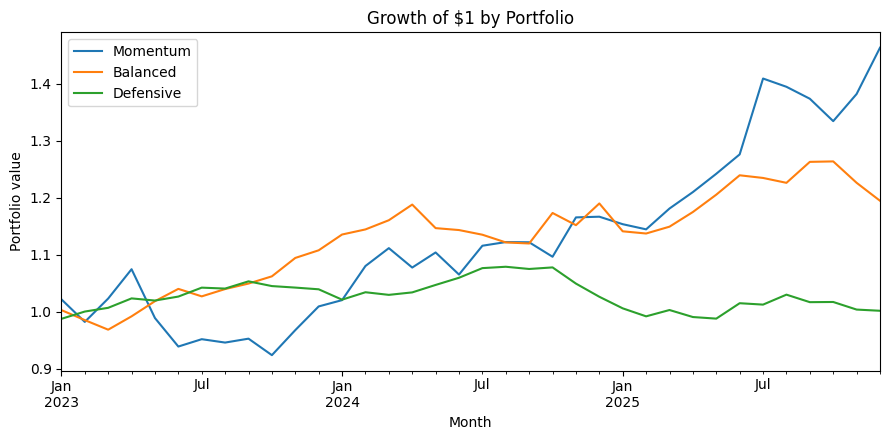

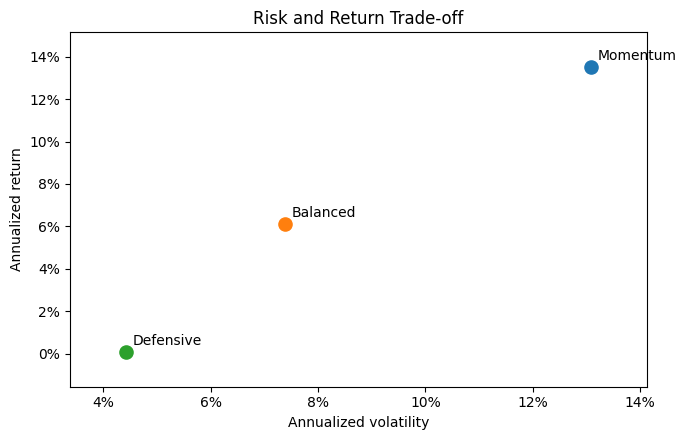

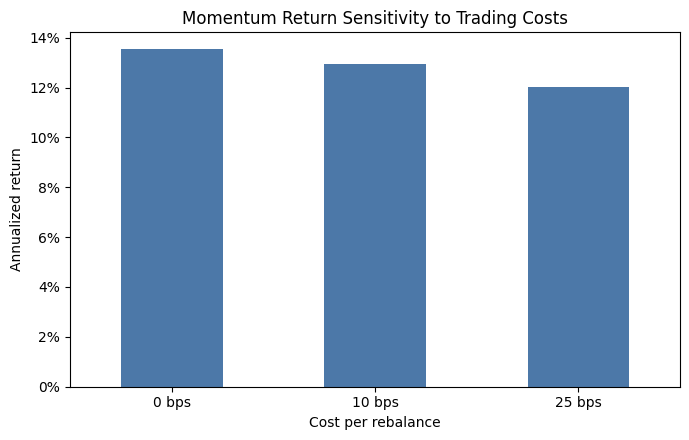

In [3]:
growth = (1 + returns).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.5))
growth.plot(ax=ax)
ax.set(title="Growth of $1 by Portfolio", xlabel="Month", ylabel="Portfolio value")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "portfolio_growth.png", dpi=250, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
for name, row in summary.iterrows():
    ax.scatter(row["annual_volatility"], row["annual_return"], s=90, label=name)
    ax.annotate(name, (row["annual_volatility"], row["annual_return"]), xytext=(5, 5), textcoords="offset points")
ax.set(title="Risk and Return Trade-off", xlabel="Annualized volatility", ylabel="Annualized return")
ax.margins(x=0.12, y=0.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
fig.tight_layout()
fig.savefig(IMAGES_DIR / "risk_return.png", dpi=250, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
sensitivity["annual_return"].plot.bar(ax=ax, color="#4C78A8")
ax.set(title="Momentum Return Sensitivity to Trading Costs", xlabel="Cost per rebalance", ylabel="Annualized return")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "cost_sensitivity.png", dpi=250, bbox_inches="tight")
plt.show()

## 4. Export the stakeholder report

In [4]:
best_return = summary["annual_return"].idxmax()
best_sharpe = summary["sharpe_zero_rf"].idxmax()
baseline_return = sensitivity.iloc[0]["annual_return"]
high_cost_return = sensitivity.loc["25 bps", "annual_return"]

report = f"""# Portfolio Scenario Report

## Executive Summary

- **{best_return}** has the highest simulated annual return.
- **{best_sharpe}** has the strongest return per unit of volatility under a zero risk-free rate.
- A 25 bps cost with six annual turns lowers Momentum's annual return from {baseline_return:.1%} to {high_cost_return:.1%}.

## Portfolio Growth

![Portfolio growth](images/portfolio_growth.png)

The chart shows the path of one dollar. The simulation is short and does not represent a full market cycle.

## Risk and Return

![Risk and return](images/risk_return.png)

Higher return is not sufficient by itself; the committee should compare it with volatility and drawdown tolerance.

## Sensitivity to Costs

![Cost sensitivity](images/cost_sensitivity.png)

The result declines as the assumed cost rises. The calculation uses constant turnover and does not model taxes or market impact.

## Assumptions and Risks

Returns are synthetic, normally generated, and independent across months. The sample has only 36 observations. Real portfolios can show regime changes, fat tails, correlation shifts, liquidity limits, and larger drawdowns.

## What This Means for You

Use Balanced as the starting comparison and treat Momentum as a higher-risk alternative. Do not approve a portfolio from this sample alone; request longer historical data, drawdown analysis, and cost estimates before a decision.
"""
(REPORTS_DIR / "final_report.md").write_text(report, encoding="utf-8")
(REPORTS_DIR / "README.md").write_text(
    "# Reports\n\nAudience: an investment committee. Markdown keeps the decision summary, charts, assumptions, and sensitivity in one reviewable file.\n",
    encoding="utf-8",
)
print(report)

# Portfolio Scenario Report

## Executive Summary

- **Momentum** has the highest simulated annual return.
- **Momentum** has the strongest return per unit of volatility under a zero risk-free rate.
- A 25 bps cost with six annual turns lowers Momentum's annual return from 13.5% to 12.0%.

## Portfolio Growth

![Portfolio growth](images/portfolio_growth.png)

The chart shows the path of one dollar. The simulation is short and does not represent a full market cycle.

## Risk and Return

![Risk and return](images/risk_return.png)

Higher return is not sufficient by itself; the committee should compare it with volatility and drawdown tolerance.

## Sensitivity to Costs

![Cost sensitivity](images/cost_sensitivity.png)

The result declines as the assumed cost rises. The calculation uses constant turnover and does not model taxes or market impact.

## Assumptions and Risks

Returns are synthetic, normally generated, and independent across months. The sample has only 36 observations. Real po

## 5. Completion check

In [5]:
required = [
    REPORTS_DIR / "final_report.md",
    REPORTS_DIR / "README.md",
    IMAGES_DIR / "portfolio_growth.png",
    IMAGES_DIR / "risk_return.png",
    IMAGES_DIR / "cost_sensitivity.png",
]
check = pd.Series({path.relative_to(HOMEWORK_DIR).as_posix(): path.exists() for path in required})
assert check.all()
check

reports/final_report.md                True
reports/README.md                      True
reports/images/portfolio_growth.png    True
reports/images/risk_return.png         True
reports/images/cost_sensitivity.png    True
dtype: bool